In [5]:
import pandas as pd
import re
import matplotlib.pyplot as plt


def parse_latency_file(filepath):
    batch_sizes = []
    latencies = []
    
    with open(filepath, 'r') as f:
        current_bs = None
        for line in f:
            bs_match = re.search(r'Batch size:\s*(\d+)', line)
            if bs_match:
                current_bs = int(bs_match.group(1))
                
            lat_match = re.search(r'Kernel time:\s*([\d.]+)\s*us', line)
            if lat_match and current_bs is not None:
                latencies.append(float(lat_match.group(1)))
                batch_sizes.append(current_bs)
                current_bs = None 
                
    return pd.DataFrame({
        'Batch Size': batch_sizes,
        'Latency (us)': latencies
    })


# Define a helper function to plot latency for a specific model
def plot_latency(df_6000, df_a40, df_h200, model_title):
    plt.figure(figsize=(10, 6))
    
    # Plotting 6000 series
    plt.plot(df_6000['Batch Size'], df_6000['Latency (us)'], 
             marker='o', linestyle='-', linewidth=2, label='6000')
    
    # Plotting A40 series
    plt.plot(df_a40['Batch Size'], df_a40['Latency (us)'], 
             marker='s', linestyle='--', linewidth=2, label='A40')
    
    # Plotting H200 series
    plt.plot(df_h200['Batch Size'], df_h200['Latency (us)'], 
             marker='^', linestyle='-.', linewidth=2, label='H200')

    # Formatting the plot
    plt.title(f'Latency vs Batch Size for {model_title}', fontsize=14)
    plt.xlabel('Batch Size', fontsize=12)
    plt.ylabel('Latency (us)', fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    
    # Optional: If you want log scale on the x-axis due to exponential batch size increases, uncomment below:
    # plt.xscale('log', base=2) 
    
    plt.tight_layout()
    plt.show()

# Define a helper function to plot latency for a list of dataframes
def plot_latency_list(dfs, model_title, labels=None, x_range=None, y_range=None):
    plt.figure(figsize=(10, 6))

    if labels is None:
        labels = [f"Series {i + 1}" for i in range(len(dfs))]

    markers = ['o', 's', '^', 'D', 'v', 'x', '*', '<', '>']
    linestyles = ['-', '--', '-.', ':']

    for i, (df, label) in enumerate(zip(dfs, labels)):
        plt.plot(
            df['Batch Size'],
            df['Latency (us)'],
            marker=markers[i % len(markers)],
            linestyle=linestyles[i % len(linestyles)],
            linewidth=2,
            label=label
        )

    plt.title(f'Latency vs Batch Size for {model_title}', fontsize=14)
    plt.xlabel('Batch Size', fontsize=12)
    plt.ylabel('Latency (us)', fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    if x_range is not None:
        plt.xlim(x_range)
    if y_range is not None:
        plt.ylim(y_range)
    plt.tight_layout()
    plt.show()

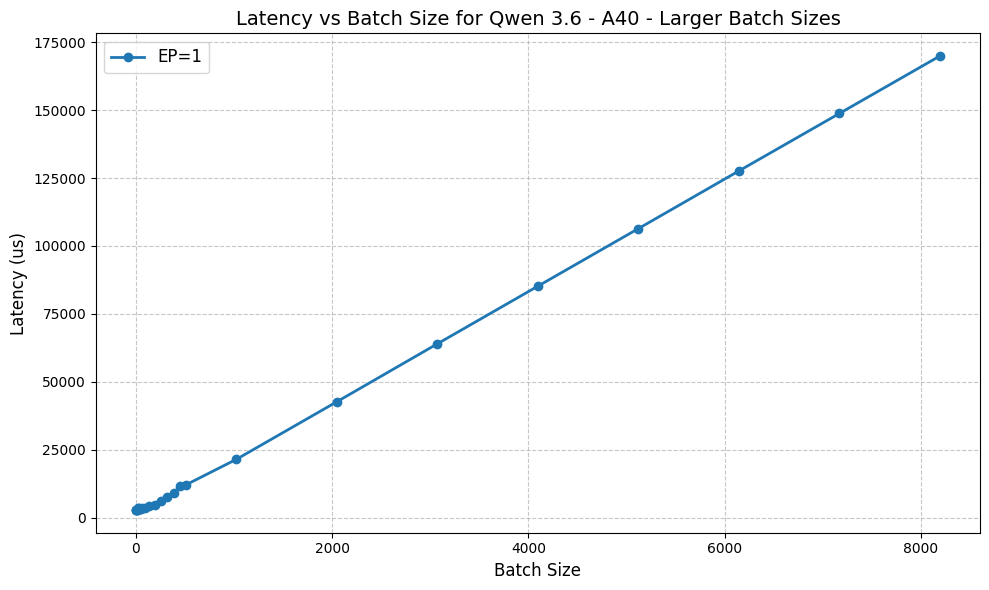

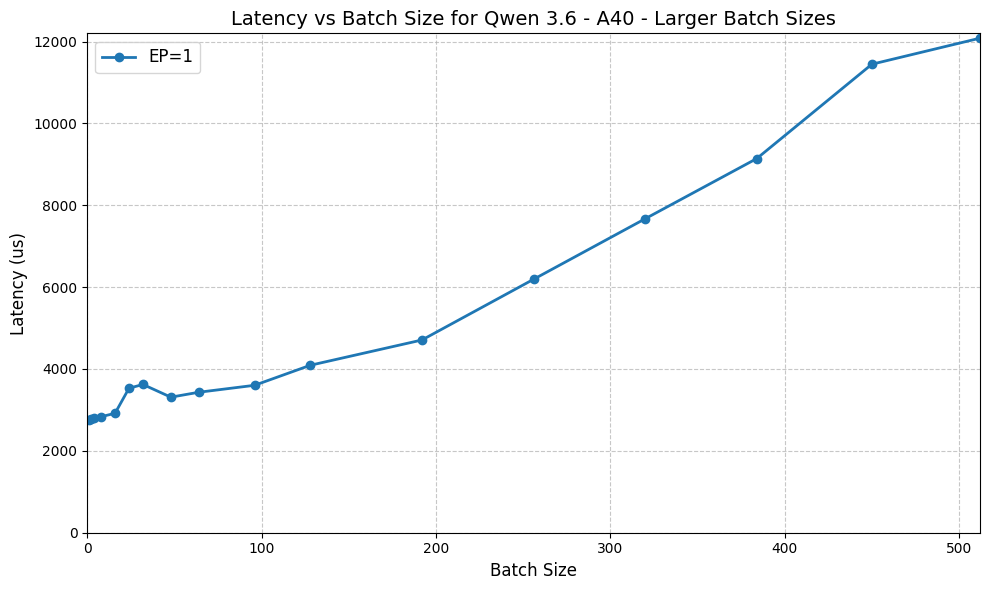

In [13]:
df_qwen_large_bs = parse_latency_file("/export2/obasit/ClusterMoE/logs/gemm_lat_vs_bs/qwen3.6_a40_large_bs.txt")

plot_latency_list(
    [df_qwen_large_bs],
    'Qwen 3.6 - A40 - Larger Batch Sizes',
    labels=['EP=1'],
)
plot_latency_list(
    [df_qwen_large_bs],
    'Qwen 3.6 - A40 - Larger Batch Sizes',
    labels=['EP=1'],
    x_range=(0, 512),
    y_range=(0, 12200)
)

# TOP-K routed graphs

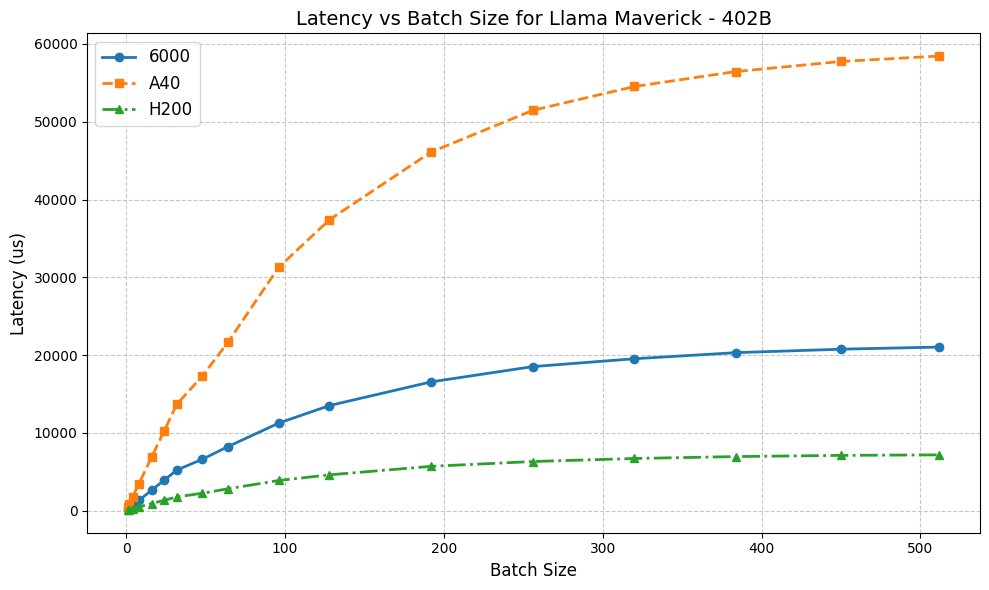

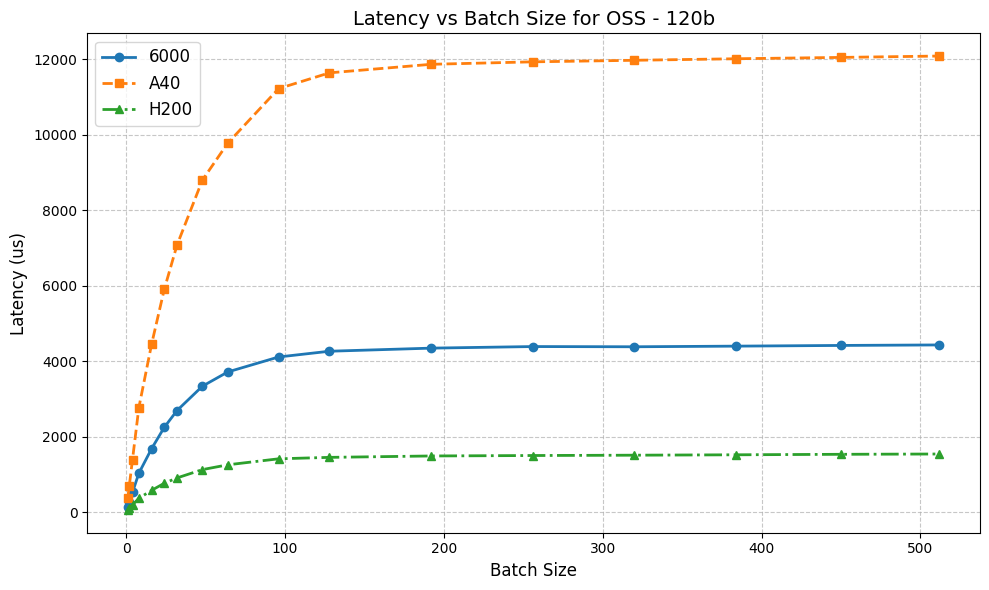

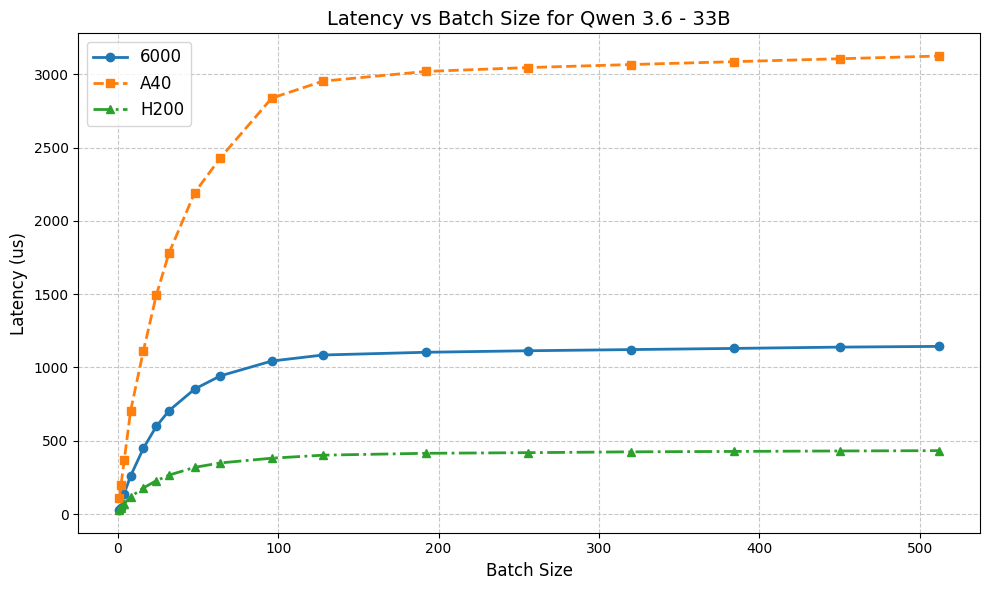

In [2]:
df_llama_6000 = parse_latency_file('../../logs/gemm_lat_vs_bs/top-k_routed_logs/llama_maverick_6000.txt')
df_oss_6000 = parse_latency_file('../../logs/gemm_lat_vs_bs/top-k_routed_logs/oss120b_6000.txt')
df_qwen_6000 = parse_latency_file('../../logs/gemm_lat_vs_bs/top-k_routed_logs/qwen3.6_6000.txt')

df_llama_a40 = parse_latency_file('../../logs/gemm_lat_vs_bs/top-k_routed_logs/llama_maverick_a40.txt')
df_oss_a40 = parse_latency_file('../../logs/gemm_lat_vs_bs/top-k_routed_logs/oss120b_a40.txt')
df_qwen_a40 = parse_latency_file('../../logs/gemm_lat_vs_bs/top-k_routed_logs/qwen3.6_a40.txt')

df_llama_h200 = parse_latency_file('../../logs/gemm_lat_vs_bs/top-k_routed_logs/llama_maverick_h200.txt')
df_oss_h200 = parse_latency_file('../../logs/gemm_lat_vs_bs/top-k_routed_logs/oss120b_h200.txt')
df_qwen_h200 = parse_latency_file('../../logs/gemm_lat_vs_bs/top-k_routed_logs/qwen3.6_h200.txt')

# Generate the three plots
plot_latency(df_llama_6000, df_llama_a40, df_llama_h200, 'Llama Maverick - 402B')
plot_latency(df_oss_6000, df_oss_a40, df_oss_h200, 'OSS - 120b')
plot_latency(df_qwen_6000, df_qwen_a40, df_qwen_h200, 'Qwen 3.6 - 33B')

## same mode, different bs and EP

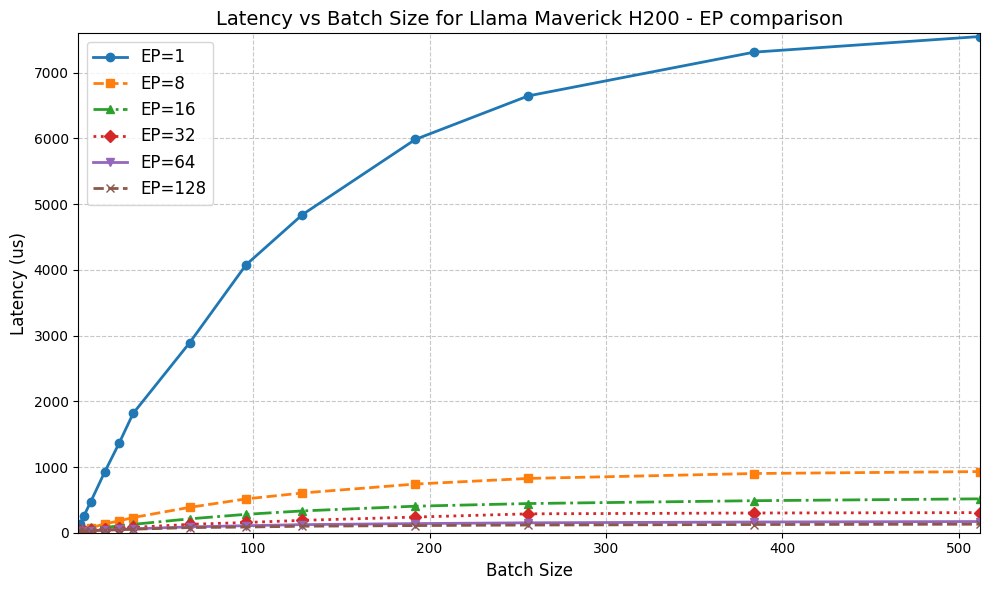

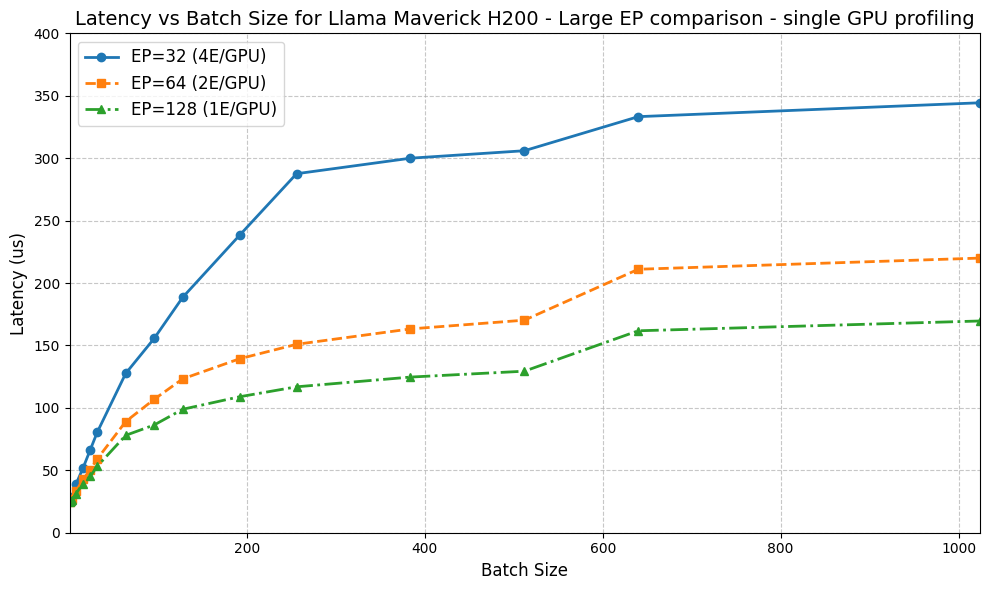

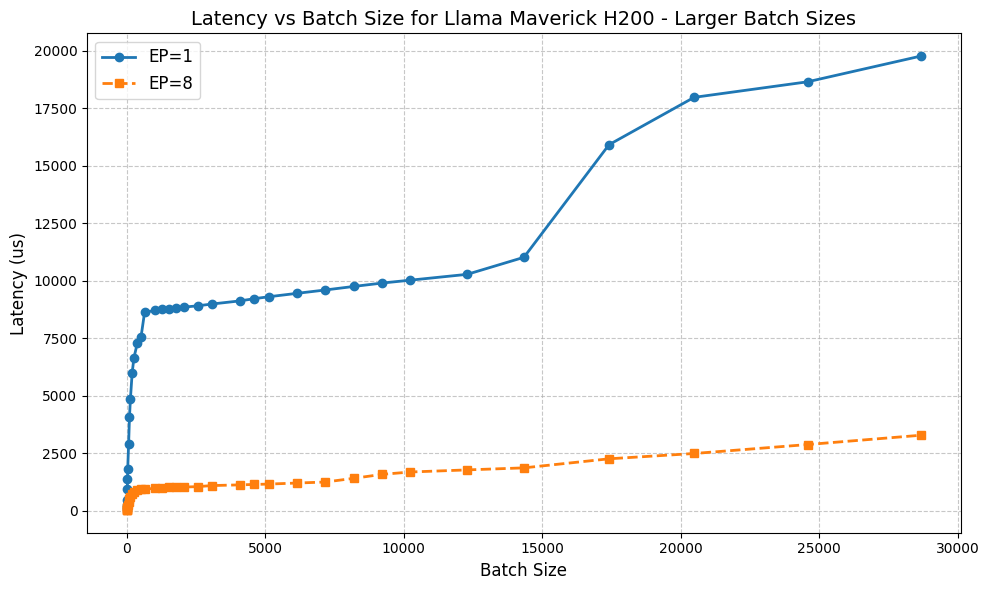

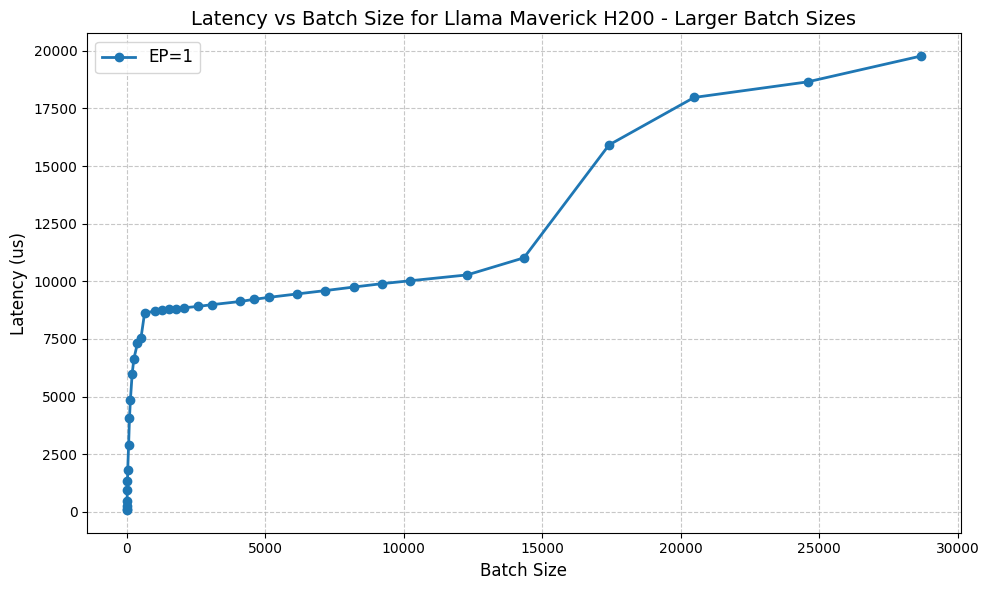

In [3]:
df_llama_ep1 = parse_latency_file('../../logs/gemm_lat_vs_bs/top-k_routed_logs/llama_maverick_h200_larger_tp1_ep1.txt')
df_llama_ep8 = parse_latency_file('../../logs/gemm_lat_vs_bs/top-k_routed_logs/llama_maverick_h200_larger_tp1_ep8.txt')
df_llama_ep16 = parse_latency_file('../../logs/gemm_lat_vs_bs/top-k_routed_logs/llama_maverick_h200_larger_tp1_ep16.txt')
df_llama_ep32 = parse_latency_file('../../logs/gemm_lat_vs_bs/top-k_routed_logs/llama_maverick_h200_larger_tp1_ep32.txt')
df_llama_ep64 = parse_latency_file('../../logs/gemm_lat_vs_bs/top-k_routed_logs/llama_maverick_h200_larger_tp1_ep64.txt')
df_llama_ep128 = parse_latency_file('../../logs/gemm_lat_vs_bs/top-k_routed_logs/llama_maverick_h200_larger_tp1_ep128.txt')

plot_latency_list(
    [df_llama_ep1, df_llama_ep8, df_llama_ep16, df_llama_ep32, df_llama_ep64, df_llama_ep128],
    'Llama Maverick H200 - EP comparison',
    labels=['EP=1', 'EP=8', 'EP=16', 'EP=32', 'EP=64', 'EP=128'],
    x_range=(1, 512),
    y_range=(0, 7600)
)

plot_latency_list(
    [df_llama_ep32, df_llama_ep64, df_llama_ep128],
    'Llama Maverick H200 - Large EP comparison - single GPU profiling',
    labels=['EP=32 (4E/GPU)', 'EP=64 (2E/GPU)', 'EP=128 (1E/GPU)'],
    x_range=(1, 1024),
    y_range=(0, 400)
)

plot_latency_list(
    [df_llama_ep1, df_llama_ep8],
    'Llama Maverick H200 - Larger Batch Sizes',
    labels=['EP=1', 'EP=8'],
)

plot_latency_list(
    [df_llama_ep1],
    'Llama Maverick H200 - Larger Batch Sizes',
    labels=['EP=1'],
)


## a40 large

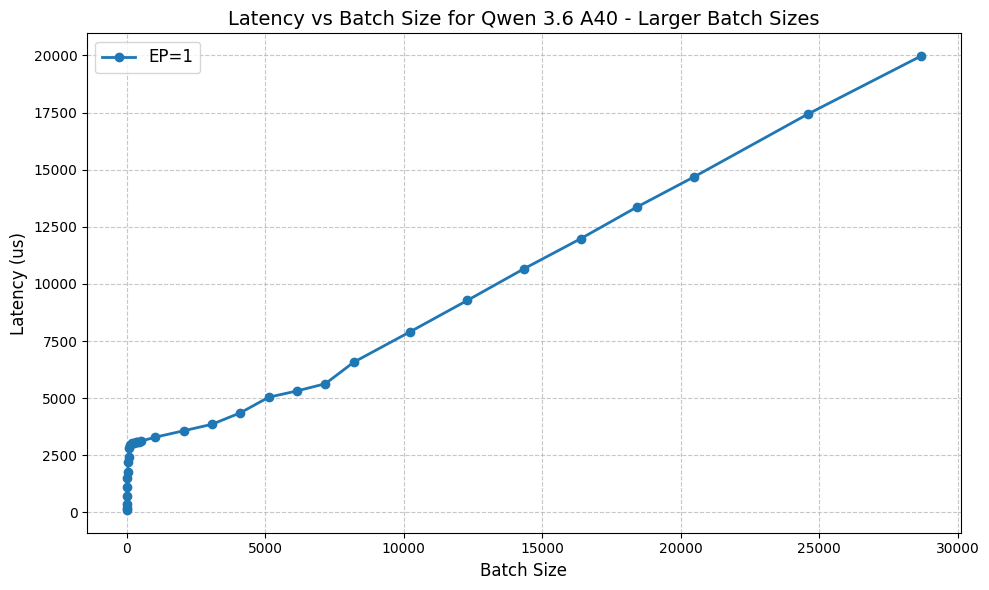

In [4]:
df_qwen_large_bs = parse_latency_file("/export2/obasit/ClusterMoE/logs/gemm_lat_vs_bs/top-k_routed_logs/qwen3.6_a40_large_bs.txt")

plot_latency_list(
    [df_qwen_large_bs],
    'Qwen 3.6 A40 - Larger Batch Sizes',
    labels=['EP=1'],
)